# Solving a 🍷red-wine Classification Problem with🌲Random Forest Classifier   



## 🎯 Objective:
This notebook demonstrates how to apply the **Random Forest** algorithm — a powerful ensemble learning method — to solve a **binary classification** problem using real-world wine quality data.

While exploring the dataset, we discovered a **class imbalance**, which posed a challenge for model performance, especially in identifying high-quality wines.

👉 In this notebook, we will:
- Understand the **core concepts** of Random Forest
- Perform **data cleaning and EDA**
- Train a model and explore **class imbalance techniques** (class weights, threshold tuning, SMOTE)
- Evaluate performance using **precision, recall, F1-score**
- Interpret model results and **highlight practical insights**

Let’s build and explain Random Forest — step by step! 🚀


## 🍷 Dataset Overview — Wine Quality Data

This dataset contains physicochemical attributes (chemical tests) of **red wine samples**, along with a **quality score** (sensorial evaluation) given by wine tasters.

- **Source**: UCI Machine Learning Repository  
- **Type**: Supervised learning (classification/regression)
- **Goal**: Predict wine `quality` based on chemical properties

### 🔍 Features (Inputs):
- `fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`
- `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, `alcohol`

### 🎯 Target (Output):
- `quality`: Integer score (typically from 3 to 8) based on human taste test  
  We'll **convert this into a binary classification** (good vs not-good wine)

Let’s load and explore the dataset! 📊


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [7]:
df = pd.read_csv("Datasets/7_winequality-red.csv", sep=';')
df.head() #";" is the sperator here

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [9]:
df.quality.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [10]:
df['quality'].describe()

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

### 🎯 Create a binary classification problem: Good (7–10) vs Not Good (≤6)

In [11]:
df['target'] = (df['quality'] >= 7).astype(int)

In [12]:
df.drop('quality', axis = 1, inplace = True)

In [13]:
print(df['target'].value_counts())

target
0    1382
1     217
Name: count, dtype: int64


As we can see that this is a class imbalance kind of statement, where most of the results are of class 0 and few in class 1.

- In ML, model has chances to predict more towards 0 rather than 1 as 0s are more.

In [15]:
X = df.drop('target',axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

Basic Random Forest Model

In [16]:
rf = RandomForestClassifier(
    n_estimators= 100, # number of trees
    max_depth = None, # no limit on depth
    max_features='sqrt',#  square root p features at each split
    random_state= 42, 
    oob_score=True # enable Out-of-Bag score
)

In [17]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Check OutofBag score (an internal cross-validation metric)

In [19]:
print("OOB Score:", rf.oob_score_)

OOB Score: 0.8936550491510277


Which indicates generalization ability without external Cross validation metric.

In [20]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # Probabilities for ROC AUC


Evaluate Model

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       415
           1       0.92      0.51      0.65        65

    accuracy                           0.93       480
   macro avg       0.92      0.75      0.81       480
weighted avg       0.93      0.93      0.92       480



In [22]:
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.9396292863762743


Confusion Matrix

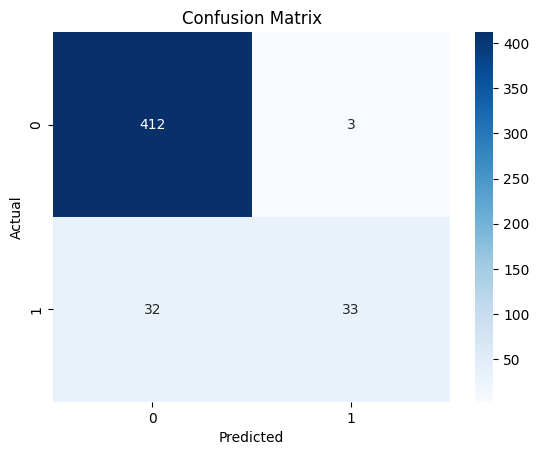

In [23]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


### Why pay attention to precision & recall for class 1?

Precision = 0.92:

When model says a wine is “good,” it’s right 92% of the time — great for avoiding false alarms.

Recall = 0.51 (Low):

But the model only identifies about half of the actual good wines. It misses many true positives (high false negatives).

Implication:

The model is conservative about labeling wines as good, which means many good wines go undetected.

### Observation

Although the precision is high for the ‘good wine’ class, the recall is quite low at 51%. 

This means while the model is confident when it predicts ‘good wine,’ it is missing nearly half of the actual good wines in the test set.

In business terms, this might mean potentially good wines are not being recognized, which could be costly if the goal is to identify all high-quality products.

Therefore, depending on the use case, we might want to improve recall even if it slightly lowers precision, for example by tuning the decision threshold or using techniques like class weighting

### What is solution  

✅ Technique: Class Weights in Random Forest
This is:

Easy to implement (just one parameter!)

Interpretable (no data duplication or resampling)

Aimed What is solution  

at improving recall for minority class (without hurting precision too much)

#### ✅ Improved model using class_weight='balanced'

In [24]:

rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)
y_pred_balanced = rf_balanced.predict(X_test)

print("Classification Report (Balanced Class Weights):")
print(classification_report(y_test, y_pred_balanced))

Classification Report (Balanced Class Weights):
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       415
           1       0.89      0.51      0.65        65

    accuracy                           0.93       480
   macro avg       0.91      0.75      0.80       480
weighted avg       0.92      0.93      0.92       480



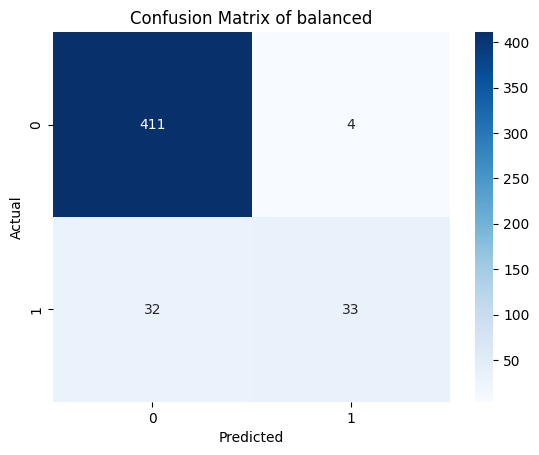

In [25]:
cm_b = confusion_matrix(y_test, y_pred_balanced)

sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix of balanced')
plt.show()
